Name | Surname | index
-|-|-
Natan | Jabłoński | 155621

# Description
Notebook contains experiments with training random forest in image segmentation

# Module import

In [1]:
import inspect
from veinClassifier.dataset import EyeDataset
from matplotlib import pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
import torch
from torch.utils.data import random_split
from veinClassifier.featureExtraction import extractDatasetPatches, extractImagePatches, extractTargets, compute_statistics_features, compute_moment_features, compute_hu_moments_features, compute_all_features
from veinClassifier.models import randomForest_train, randomForest_eval
from veinClassifier.presentation import eval_model, predict_test_patches
import joblib
from sklearn.model_selection import train_test_split 
from IPython.display import Markdown, display

# Preprocessing

## Dataset import

# Bare random forest

## Random forest on 1M raw patches

In [2]:
project_root = Path().cwd().parent

dataset = EyeDataset(project_root / "data/healthy/", project_root / "data/healthy_manualsegm")

img, segm = dataset[0]

### Image patch extraction
Random forest will not be trained on full images, but instead on small patches of them with an aim to predict the middle pixel on the image. Therefore each image needs to be split in those patches. 

Each image is big and produces a considerable amount of patches. Patches from all images would not fit into memory, so extracting method has an upper limit on amount of patches it will return. 

Alas the pure pytorch datasets cannot be used here. Random tree is no trained in batches. Therefore pytorch dataset is used only for accessing the images and the dataset itself is stored in form of an array.

In [3]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=1000000)

print(sample_patches.shape)
print(sample_targets.shape)

  7%|███████████████▏                                                                                                                                                                                                                    | 1/15 [00:07<01:48,  7.73s/it]


torch.Size([1667776, 75])
torch.Size([1667776])


### trainig

In [4]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_pure_1M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Training and evaluation 

In [5]:
display(Markdown(f"""
train method: 
```python
{inspect.getsource(randomForest_train)}
```

eval method: 
```python
{inspect.getsource(randomForest_eval)}
```

"""))


train method: 
```python
def randomForest_train(X_train, y_train):
      
    # Create model  
    model = RandomForestClassifier(  
        n_estimators=50, 
        max_depth=25, 
        random_state=42,
        n_jobs=-1
    )  
      
    # Train  
    model.fit(X_train, y_train)  
    return model

```

eval method: 
```python
def randomForest_eval(model, X_test):
    # Predict  
    y_pred = model.predict(X_test) 
    return y_pred

```



### Evaluation

In [6]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

Accuracy: 0.9197556032570243
Precision: 0.9463376544228743
Recall: 0.8905915809346285
F1: 0.9176187427670943

Classification report:
               precision    recall  f1-score   support

         0.0       0.90      0.95      0.92    166174
         1.0       0.95      0.89      0.92    167382

    accuracy                           0.92    333556
   macro avg       0.92      0.92      0.92    333556
weighted avg       0.92      0.92      0.92    333556


Confusion matrix:
 [[157721   8453]
 [ 18313 149069]]


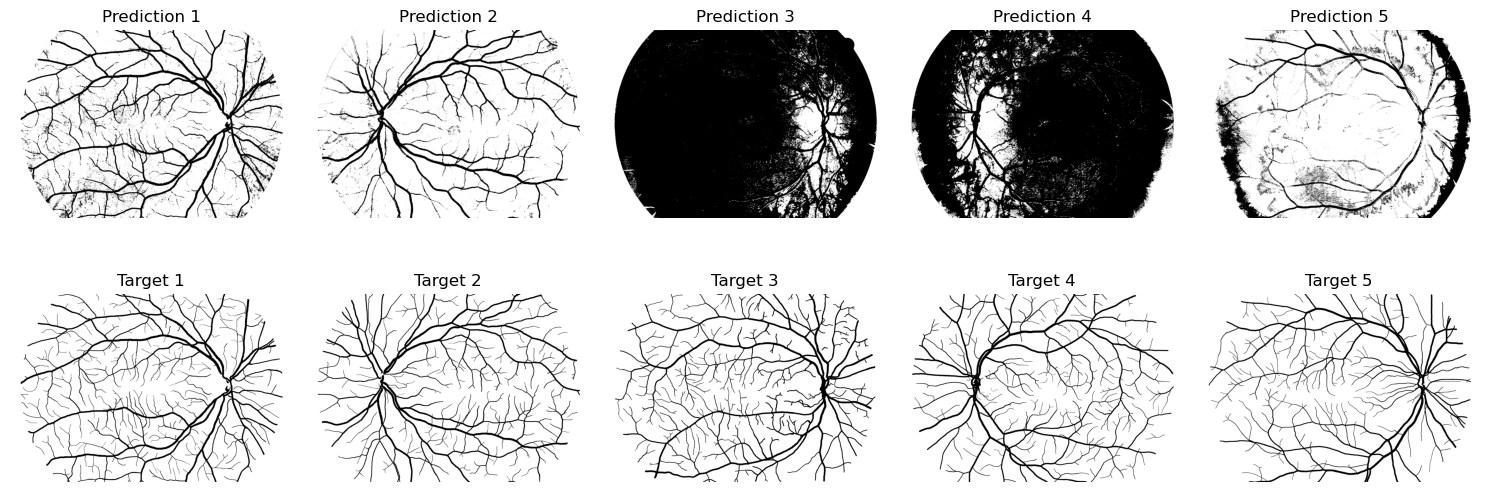

In [7]:
predict_test_patches(model, dataset)

## Random forest on 5M raw patches

### Data preparation

In [8]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=5000000)

print(sample_patches.shape)
print(sample_targets.shape)

 20%|█████████████████████████████████████████████▌                                                                                                                                                                                      | 3/15 [00:17<01:10,  5.87s/it]


torch.Size([5012994, 75])
torch.Size([5012994])


### Training

In [9]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_pure_5M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [10]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

Accuracy: 0.7935126605951133
Precision: 0.7551233278027311
Recall: 0.8684109679814459
F1: 0.8078146322444092

Classification report:
               precision    recall  f1-score   support

         0.0       0.85      0.72      0.78    501577
         1.0       0.76      0.87      0.81    501022

    accuracy                           0.79   1002599
   macro avg       0.80      0.79      0.79   1002599
weighted avg       0.80      0.79      0.79   1002599


Confusion matrix:
 [[360482 141095]
 [ 65929 435093]]


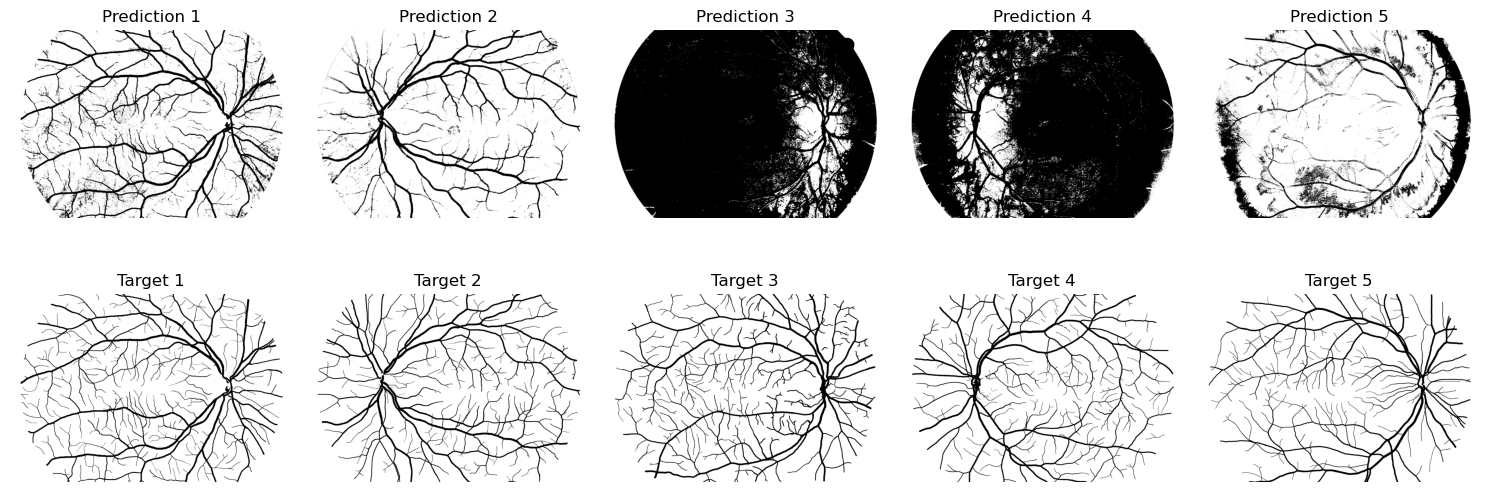

In [11]:
predict_test_patches(model, dataset)

## Random forest on all raw patches

### Data preparation

In [12]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=-1)

print(sample_patches.shape)
print(sample_targets.shape)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [01:09<00:00,  4.62s/it]


torch.Size([22859916, 75])
torch.Size([22859916])


### Training

In [13]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_pure_all.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [14]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

Accuracy: 0.861459488922096
Precision: 0.8973141427770464
Recall: 0.8163312176473496
F1: 0.8549091471341118

Classification report:
               precision    recall  f1-score   support

         0.0       0.83      0.91      0.87   2286043
         1.0       0.90      0.82      0.85   2285941

    accuracy                           0.86   4571984
   macro avg       0.86      0.86      0.86   4571984
weighted avg       0.86      0.86      0.86   4571984


Confusion matrix:
 [[2072494  213549]
 [ 419856 1866085]]


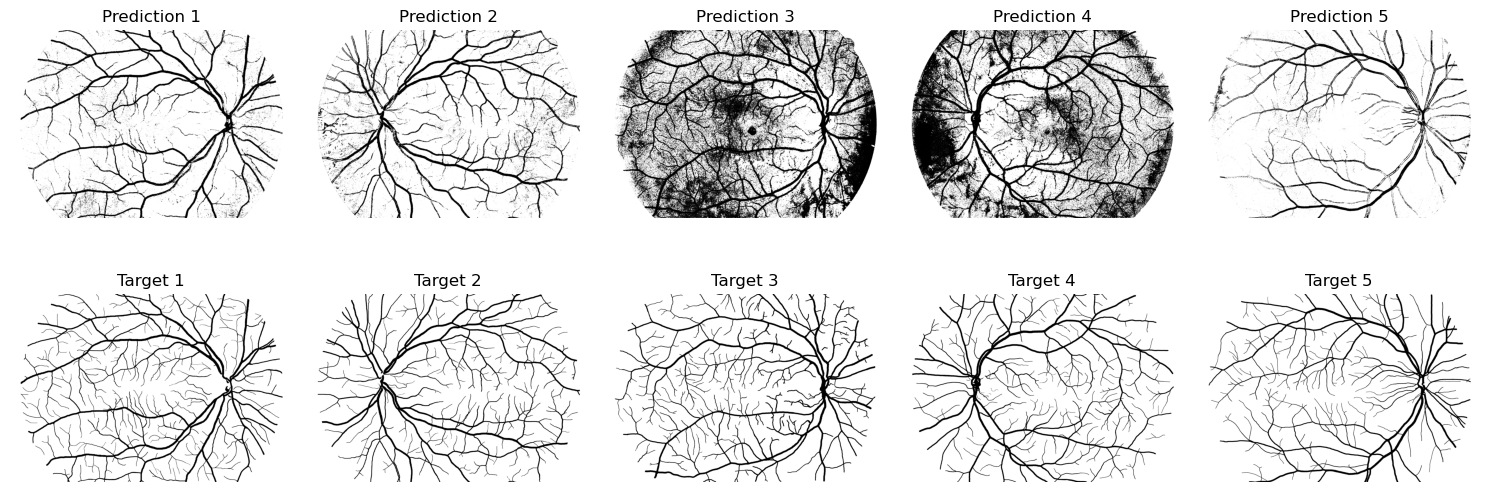

In [15]:
predict_test_patches(model, dataset)

# Random forest on statistics patches

## Random forest on 1M patches

### Data preparation

In [16]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=1000000)

print(sample_patches.shape)
print(sample_targets.shape)

  7%|███████████████▏                                                                                                                                                                                                                    | 1/15 [00:07<01:39,  7.11s/it]


torch.Size([1667776, 75])
torch.Size([1667776])


### Computing statistic

In [17]:
sample_patches = compute_statistics_features(sample_patches)

### Training

In [18]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_statistics_1M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [19]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

Accuracy: 0.8552027245799806
Precision: 0.8465556854841079
Recall: 0.8665571936409405
F1: 0.856439675415391

Classification report:
               precision    recall  f1-score   support

         0.0       0.86      0.84      0.85    167305
         1.0       0.85      0.87      0.86    166251

    accuracy                           0.86    333556
   macro avg       0.86      0.86      0.86    333556
weighted avg       0.86      0.86      0.86    333556


Confusion matrix:
 [[141192  26113]
 [ 22185 144066]]


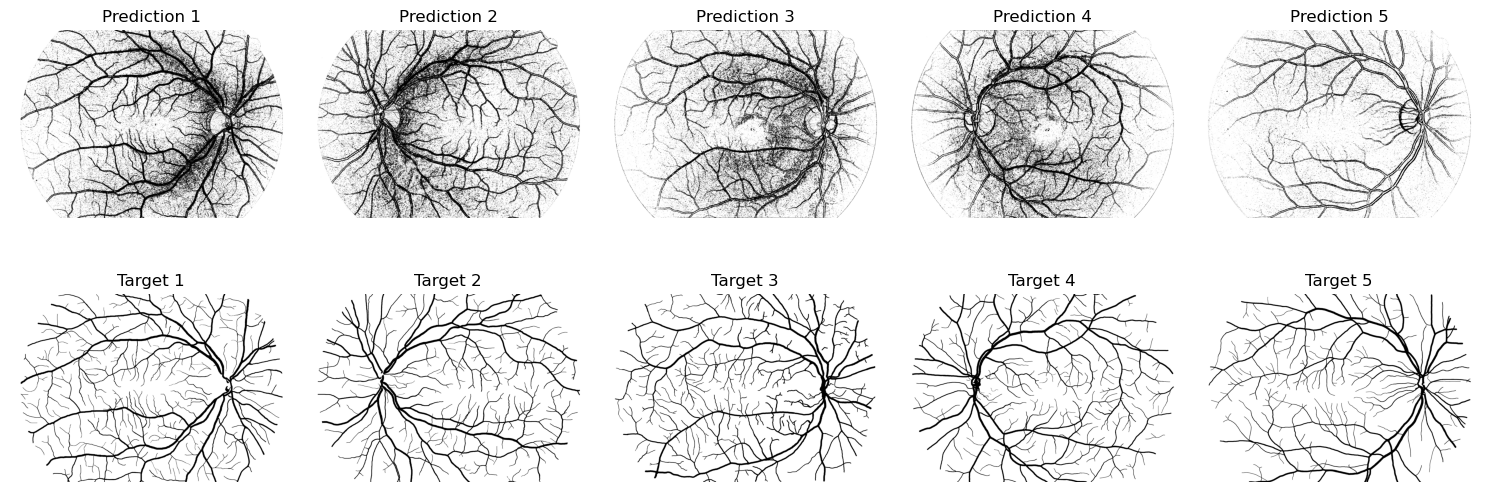

In [20]:
predict_test_patches(model, dataset, compute_statistics_features)

## Random forest on 5M statistic patches

### Data preparation

In [21]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=5000000)

print(sample_patches.shape)
print(sample_targets.shape)

 20%|█████████████████████████████████████████████▌                                                                                                                                                                                      | 3/15 [00:17<01:10,  5.85s/it]


torch.Size([5012994, 75])
torch.Size([5012994])


### Computing statistic

In [22]:
sample_patches = compute_statistics_features(sample_patches)

### Training

In [23]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_statistics_5M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [24]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

Accuracy: 0.8319447755284017
Precision: 0.8345260343377449
Recall: 0.8284990025767598
F1: 0.8315015970606883

Classification report:
               precision    recall  f1-score   support

         0.0       0.83      0.84      0.83    500806
         1.0       0.83      0.83      0.83    501793

    accuracy                           0.83   1002599
   macro avg       0.83      0.83      0.83   1002599
weighted avg       0.83      0.83      0.83   1002599


Confusion matrix:
 [[418372  82434]
 [ 86058 415735]]


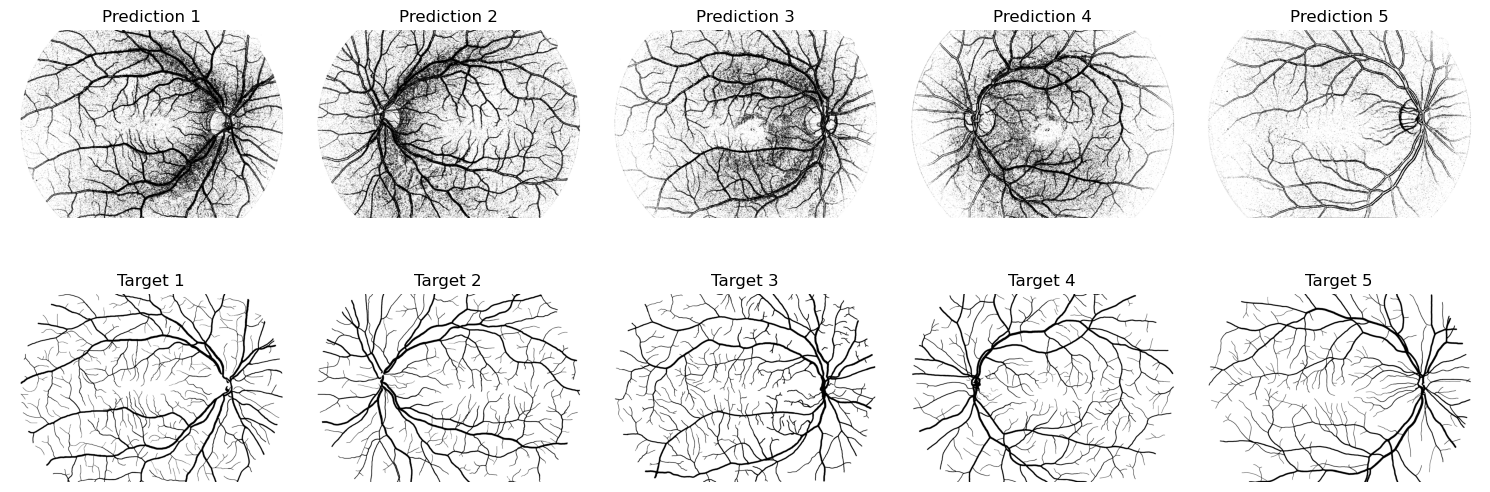

In [25]:
predict_test_patches(model, dataset, compute_statistics_features)

## Random forest on all statistic patches

### Data preparation

In [26]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=-1)

print(sample_patches.shape)
print(sample_targets.shape)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [01:08<00:00,  4.57s/it]


torch.Size([22859916, 75])
torch.Size([22859916])


### Computing statistic

In [27]:
sample_patches = compute_statistics_features(sample_patches)

### Training

In [28]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_statistics_all.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [29]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

Accuracy: 0.7561616576086005
Precision: 0.7861854058806291
Recall: 0.7039131113566861
F1: 0.7427780227346088

Classification report:
               precision    recall  f1-score   support

         0.0       0.73      0.81      0.77   2285287
         1.0       0.79      0.70      0.74   2286697

    accuracy                           0.76   4571984
   macro avg       0.76      0.76      0.76   4571984
weighted avg       0.76      0.76      0.76   4571984


Confusion matrix:
 [[1847523  437764]
 [ 677061 1609636]]


In [ ]:
predict_test_patches(model, dataset, compute_statistics_features)

# Random forest on moments patches

## Random forest on 1M moments patches

### Data preparation

In [ ]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=1000000)

print(sample_patches.shape)
print(sample_targets.shape)

### Computing statistic

In [ ]:
sample_patches = compute_moment_features(sample_patches)

### Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_moments_1M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [ ]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

In [ ]:
predict_test_patches(model, dataset, compute_moment_features)

## Random forest on 5M moments patches

### Data preparation

In [ ]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=5000000)

print(sample_patches.shape)
print(sample_targets.shape)

### Computing statistic

In [ ]:
sample_patches = compute_moment_features(sample_patches)

### Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_moments_5M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [ ]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

In [ ]:
predict_test_patches(model, dataset, compute_moment_features)

## Random forest on all moments patches

### Data preparation

In [ ]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=-1)

print(sample_patches.shape)
print(sample_targets.shape)

### Computing statistic

In [ ]:
sample_patches = compute_moment_features(sample_patches)

### Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_moments_all.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [ ]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

In [ ]:
predict_test_patches(model, dataset, compute_moment_features)

# Random forest on hu patches

## Random forest on 1M hu patches

### Data preparation

In [ ]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=1000000)

print(sample_patches.shape)
print(sample_targets.shape)

### Computing statistic

In [ ]:
sample_patches = compute_hu_moments_features(sample_patches)

### Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_hu_1M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [ ]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

In [ ]:
predict_test_patches(model, dataset, compute_hu_moments_features)

## Random forest on 5M hu patches

### Data preparation

In [ ]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=5000000)

print(sample_patches.shape)
print(sample_targets.shape)

### Computing statistic

In [ ]:
sample_patches = compute_hu_moments_features(sample_patches)

### Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_hu_5M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [ ]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

In [ ]:
predict_test_patches(model, dataset, compute_hu_moments_features)

## Random forest on all hu patches

### Data preparation

In [ ]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=-1)

print(sample_patches.shape)
print(sample_targets.shape)

### Computing statistic

In [ ]:
sample_patches = compute_hu_moments_features(sample_patches)

### Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_hu_all.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [ ]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

In [ ]:
predict_test_patches(model, dataset, compute_hu_moments_features)

# Random forest on all_features patches

## Random forest on 1M all_features patches

### Data preparation

In [ ]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=1000000)

print(sample_patches.shape)
print(sample_targets.shape)

### Computing statistic

In [ ]:
sample_patches = compute_all_features(sample_patches)

### Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_all_features_1M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [ ]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

In [ ]:
predict_test_patches(model, dataset, compute_all_features)

## Random forest on 5M all_features patches

### Data preparation

In [ ]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=5000000)

print(sample_patches.shape)
print(sample_targets.shape)

### Computing statistic

In [ ]:
sample_patches = compute_all_features(sample_patches)

### Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_all_features_5M.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [ ]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

In [ ]:
predict_test_patches(model, dataset, compute_all_features)

## Random forest on all all_features patches

### Data preparation

In [ ]:
sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=-1)

print(sample_patches.shape)
print(sample_targets.shape)

### Computing statistic

In [ ]:
sample_patches = compute_all_features(sample_patches)

### Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

modelPath = project_root / "savedModels/randomForest_all_features_all.pkl"
if modelPath.exists() :
    model = joblib.load(modelPath)
else:
    model = randomForest_train(X_train, y_train)
    joblib.dump(model, modelPath)

### Evaluation

In [ ]:
y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

In [ ]:
predict_test_patches(model, dataset, compute_all_features)

